In [1]:
import re
import string
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

In [2]:
text = """
Welcome to TechIndia 2024 — India's Biggest Technology Conference!

The event will be held on 15th January 2024 at Pragati Maidan, New Delhi.
The registration deadline is 5th December 2023. Late registrations will be
accepted until 10th January 2024 with an additional fee.

For queries, contact our organizing team:
  - General Inquiries : contact@techindia.com
  - Speaker Relations : speakers@techindia.com
  - Sponsorship Team  : sponsors@techindia.in
  - Media & Press     : press@mediatech.org

You can also reach us by phone:
  - Helpline          : +91-9876543210
  - Delhi Office      : +91-1123456789
  - Mumbai Office     : +91-9988776655
  - Bangalore Office  : +91-8765432109

Visit our official website at www.techindia.com for the full schedule.
Sponsorship packages are available at www.sponsors.techindia.com.
Press kit can be downloaded from www.press.techindia.in.

Conference Timings:
  Day 1  — 10:30 AM to 06:00 PM
  Day 2  — 09:00 AM to 05:30 PM
  Day 3  — 10:00 AM to 04:00 PM

Ticket Prices:
  - Student Pass      : Rs.999
  - General Pass      : Rs.2499
  - VIP Pass          : Rs.7999
  - Corporate Bundle  : Rs.24999

Key topics at this year's conference include artificial intelligence,
machine learning, deep learning, natural language processing, computer
vision, cloud computing, and blockchain innovation. Sessions will be
conducted by leading experts who are pioneering transformation across
industries including healthcare, education, and manufacturing.

Confirmed speakers include Dr. Rajesh Sharma from IIT Delhi, Ms. Priya
Mehta from Google India, Mr. Arjun Kapoor from Microsoft India, and
Dr. Anita Rao from Anthropic Research. Each speaker will be presenting
groundbreaking research and sharing inspiring stories of innovation,
collaboration, and transformation.

Workshops include hands-on sessions on implementing machine learning
pipelines, building intelligent chatbots, deploying cloud solutions,
and optimizing production systems. Participants completing all sessions
will receive certification from TechIndia Foundation.

Follow us on social media:
  #TechIndia2024
  #AIConference
  #MachineLearning2024
  #FutureOfTech
  #InnovationIndia

We look forward to welcoming innovators, researchers, engineers, and
entrepreneurs from across the nation. See you in Delhi!

For more information visit www.techindia.com or email contact@techindia.com.
"""

print("Total characters in text:", len(text))
print("Total words in text     :", len(text.split()))

Total characters in text: 2393
Total words in text     : 317


In [3]:
# ==========================================
# STEP 2: EXTRACT EMAIL ADDRESSES
# ==========================================

# Regex pattern for emails:
# [a-zA-Z0-9._%+-]+ = username part (letters, digits, dots, etc.)
# @                  = the @ symbol
# [a-zA-Z0-9.-]+    = domain name
# \.[a-zA-Z]{2,}    = extension like .com .in .org

email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
emails        = re.findall(email_pattern, text)

print("Emails found:", len(emails))
print()
for email in emails:
    print(" ", email)

Emails found: 5

  contact@techindia.com
  speakers@techindia.com
  sponsors@techindia.in
  press@mediatech.org
  contact@techindia.com


In [4]:
# ==========================================
# STEP 3: EXTRACT PHONE NUMBERS
# ==========================================

# Regex pattern for Indian phone numbers:
# \+91   = country code
# -      = hyphen separator
# \d{10} = exactly 10 digits

phone_pattern = r'\+91-\d{10}'
phones        = re.findall(phone_pattern, text)

print("Phone numbers found:", len(phones))
print()
for phone in phones:
    print(" ", phone)

Phone numbers found: 4

  +91-9876543210
  +91-1123456789
  +91-9988776655
  +91-8765432109


In [6]:
# ==========================================
# STEP 4: EXTRACT DATES
# ==========================================

# Regex pattern for dates like "15th January 2024"
# \d{1,2}  = 1 or 2 digit day number
# (?:st|nd|rd|th) = ordinal suffix
# [A-Z][a-z]+ = month name starting with capital
# \d{4}    = 4 digit year

date_pattern = r'\d{1,2}(?:st|nd|rd|th)\s[A-Z][a-z]+\s\d{4}'
dates        = re.findall(date_pattern, text)

print("Dates found:", len(dates))
print()
for date in dates:
    print(" ", date)

Dates found: 3

  15th January 2024
  5th December 2023
  10th January 2024


In [7]:
# ==========================================
# STEP 5: EXTRACT URLs
# ==========================================

# Regex pattern for URLs starting with www.
# www\.       = literal www.
# [a-zA-Z0-9.-]+ = domain characters
# \.[a-zA-Z]{2,} = extension

url_pattern = r'www\.[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
urls        = re.findall(url_pattern, text)

print("URLs found:", len(urls))
print()
for url in urls:
    print(" ", url)

URLs found: 4

  www.techindia.com
  www.sponsors.techindia.com
  www.press.techindia.in
  www.techindia.com


In [8]:
# ==========================================
# STEP 6: EXTRACT PRICES
# ==========================================

# Regex pattern for prices like Rs.999 or Rs.24999
# Rs\.   = literal Rs.
# \d+    = one or more digits

price_pattern = r'Rs\.\d+'
prices        = re.findall(price_pattern, text)

print("Prices found:", len(prices))
print()
for price in prices:
    print(" ", price)

Prices found: 4

  Rs.999
  Rs.2499
  Rs.7999
  Rs.24999


In [9]:
# ==========================================
# STEP 7: EXTRACT TIMES
# ==========================================

# Regex pattern for times like 10:30 AM or 06:00 PM
# \d{1,2}  = hour (1 or 2 digits)
# :        = colon separator
# \d{2}    = minutes (exactly 2 digits)
# \s?      = optional space
# [AP]M    = AM or PM

time_pattern = r'\d{1,2}:\d{2}\s[AP]M'
times        = re.findall(time_pattern, text)

print("Times found:", len(times))
print()
for time in times:
    print(" ", time)

Times found: 6

  10:30 AM
  06:00 PM
  09:00 AM
  05:30 PM
  10:00 AM
  04:00 PM


In [10]:
# ==========================================
# STEP 8: EXTRACT HASHTAGS
# ==========================================

# Regex pattern for hashtags
# #        = literal hash symbol
# \w+      = one or more word characters (letters, digits, underscore)

hashtag_pattern = r'#\w+'
hashtags        = re.findall(hashtag_pattern, text)

print("Hashtags found:", len(hashtags))
print()
for tag in hashtags:
    print(" ", tag)

Hashtags found: 5

  #TechIndia2024
  #AIConference
  #MachineLearning2024
  #FutureOfTech
  #InnovationIndia


In [11]:
# ==========================================
# STEP 9: WORDS ENDING IN "ing" AND "tion"
# ==========================================

# Extract all words ending in "ing"
ing_pattern  = r'\b\w+ing\b'
ing_words    = re.findall(ing_pattern, text.lower())

# Extract all words ending in "tion"
tion_pattern = r'\b\w+tion\b'
tion_words   = re.findall(tion_pattern, text.lower())

print("Words ending in 'ing' :", ing_words)
print()
print("Words ending in 'tion':", tion_words)

Words ending in 'ing' : ['organizing', 'learning', 'learning', 'processing', 'computing', 'leading', 'pioneering', 'including', 'manufacturing', 'presenting', 'groundbreaking', 'sharing', 'inspiring', 'implementing', 'learning', 'building', 'deploying', 'optimizing', 'completing', 'welcoming']

Words ending in 'tion': ['registration', 'innovation', 'transformation', 'education', 'innovation', 'collaboration', 'transformation', 'production', 'certification', 'foundation', 'nation', 'information']


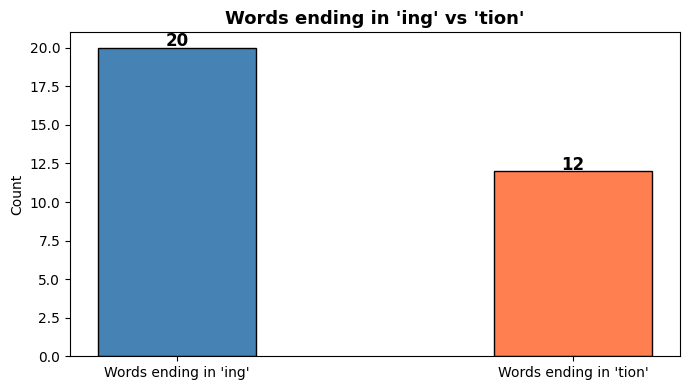

In [12]:
# Plot ing vs tion word counts
categories = ["Words ending in 'ing'", "Words ending in 'tion'"]
counts     = [len(ing_words), len(tion_words)]

plt.figure(figsize=(7, 4))
bars = plt.bar(categories, counts, color=["steelblue", "coral"], edgecolor="black", width=0.4)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(count), ha="center", fontweight="bold", fontsize=12)

plt.title("Words ending in 'ing' vs 'tion'", fontweight="bold", fontsize=13)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# STEP 10: WORD FREQUENCY
# ==========================================

# Remove punctuation and convert to lowercase
clean_text = text.lower()
clean_text = re.sub(r'[^a-z\s]', '', clean_text)

# Split into individual words
all_words  = clean_text.split()

# Count frequency of each word
word_freq  = Counter(all_words)

# Convert to DataFrame
freq_df = pd.DataFrame(word_freq.items(), columns=["Word", "Count"])
freq_df = freq_df.sort_values("Count", ascending=False).reset_index(drop=True)

print("Total unique words:", len(freq_df))
freq_df.head(15)

Total unique words: 185


,Word,Count
0,from,7
1,and,7
2,will,5
3,be,5
4,to,5
5,delhi,4
6,rs,4
7,the,4
8,at,4
9,on,3


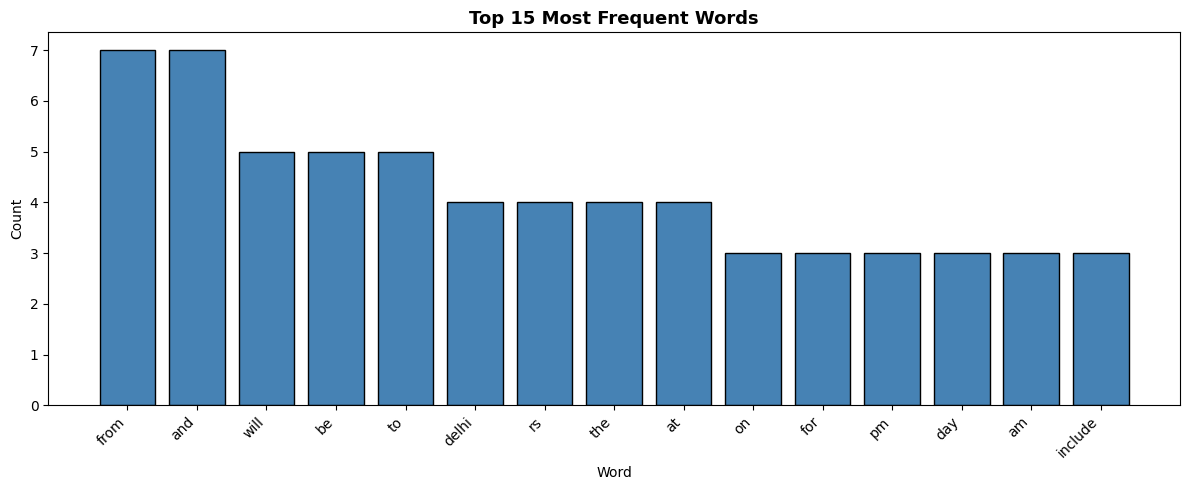

In [14]:
# Plot top 15 most frequent words
top15 = freq_df.head(15)

plt.figure(figsize=(12, 5))
plt.bar(top15["Word"], top15["Count"], color="steelblue", edgecolor="black")
plt.title("Top 15 Most Frequent Words", fontweight="bold", fontsize=13)
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# STEP 11: TOP WORDS AFTER REMOVING STOPWORDS
# ==========================================

# Stopwords are common words like "the", "is", "and", "to"
# They appear very frequently but carry no meaningful information
# Removing them reveals the actual important words in the text

stopwords = set([
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to",
    "for", "of", "with", "by", "from", "is", "are", "was", "were",
    "be", "been", "will", "can", "all", "our", "us", "we", "you",
    "your", "their", "this", "that", "it", "its", "as", "also",
    "each", "more", "across", "include", "including", "full"
])

filtered_words = [word for word in all_words if word not in stopwords]
filtered_freq  = Counter(filtered_words)

filtered_df = pd.DataFrame(filtered_freq.items(), columns=["Word", "Count"])
filtered_df = filtered_df.sort_values("Count", ascending=False).reset_index(drop=True)

print("Top 15 words after removing stopwords:")
filtered_df.head(15)

Top 15 words after removing stopwords:


,Word,Count
0,delhi,4
1,rs,4
2,th,3
3,conference,3
4,pass,3
5,learning,3
6,am,3
7,day,3
8,office,3
9,techindia,3


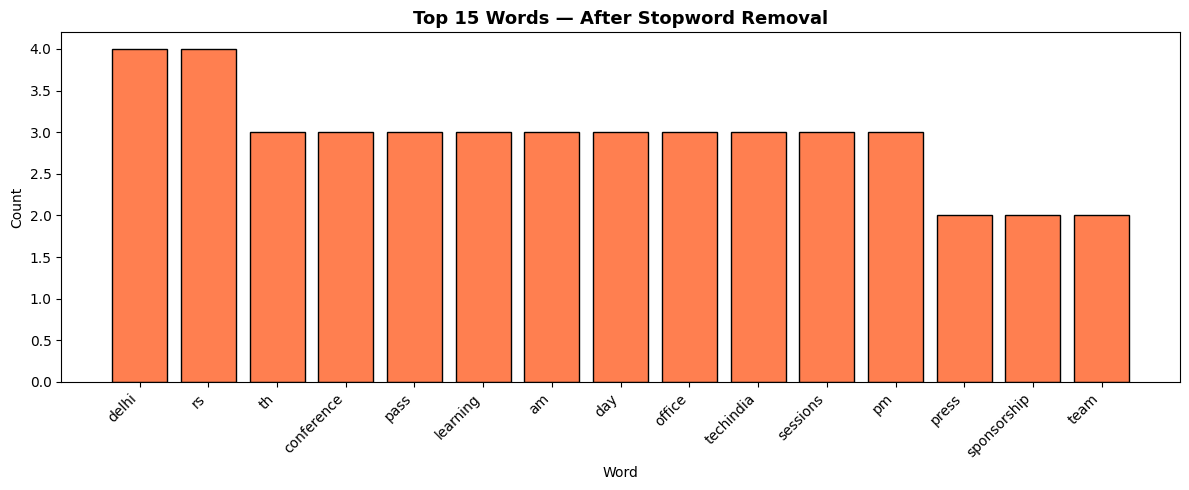

In [16]:
# Plot top 15 words after stopword removal
top15_filtered = filtered_df.head(15)

plt.figure(figsize=(12, 5))
plt.bar(top15_filtered["Word"], top15_filtered["Count"], color="coral", edgecolor="black")
plt.title("Top 15 Words — After Stopword Removal", fontweight="bold", fontsize=13)
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

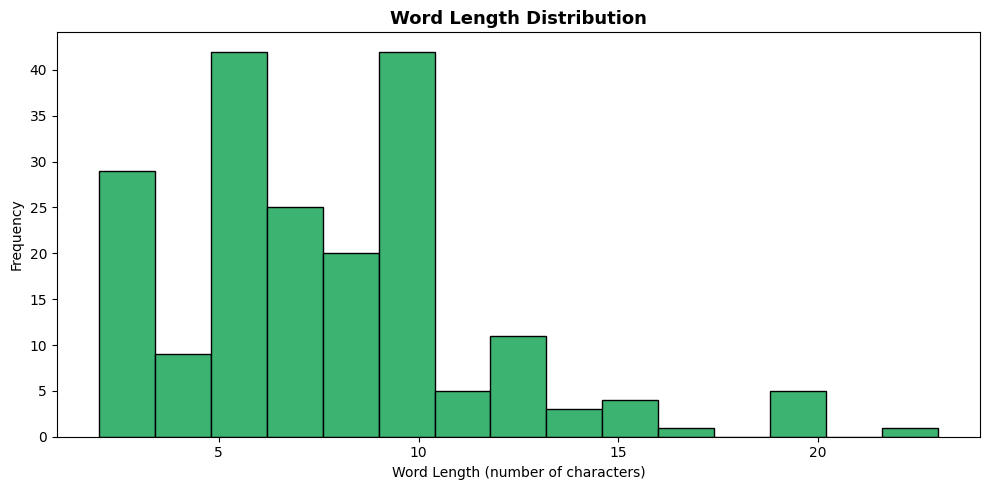

In [17]:
# ==========================================
# STEP 12: WORD LENGTH DISTRIBUTION
# ==========================================

# Calculate length of every unique word
word_lengths = [len(word) for word in filtered_words]

plt.figure(figsize=(10, 5))
plt.hist(word_lengths, bins=15, color="mediumseagreen", edgecolor="black")
plt.title("Word Length Distribution", fontweight="bold", fontsize=13)
plt.xlabel("Word Length (number of characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [18]:
# ==========================================
# STEP 13: TOP 10 LONGEST WORDS
# ==========================================

unique_words  = list(set(filtered_words))
longest_words = sorted(unique_words, key=len, reverse=True)[:10]

longest_df = pd.DataFrame({
    "Word"   : longest_words,
    "Length" : [len(w) for w in longest_words]
})

print(longest_df)

                      Word  Length
0  wwwsponsorstechindiacom      23
1     speakerstechindiacom      20
2      sponsorstechindiain      19
3      contacttechindiacom      19
4      wwwpresstechindiain      19
5        pressmediatechorg      17
6          wwwtechindiacom      15
7          machinelearning      15
8          innovationindia      15
9           groundbreaking      14


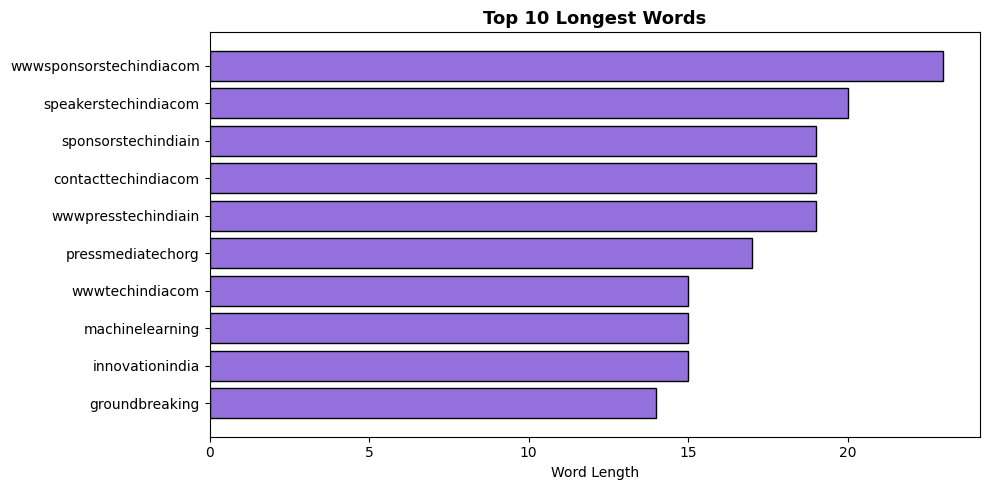

In [19]:
# Plot top 10 longest words
plt.figure(figsize=(10, 5))
plt.barh(longest_df["Word"], longest_df["Length"], color="mediumpurple", edgecolor="black")
plt.title("Top 10 Longest Words", fontweight="bold", fontsize=13)
plt.xlabel("Word Length")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()